# **Retail Churn Prediction - Modeling**
---
**Goal:** Train 6 classifiers (unoptimized + optimized) and compare performance  
**Best Model:** XGBoost (F1: 0.9648)  

## 1. Import Libraries

In [2]:

%pip install xgboost
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
import warnings
import os
warnings.filterwarnings('ignore')
sns.set(style="whitegrid")
print("All libraries imported!")

  Using cached xgboost-3.1.1-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.1.1-py3-none-win_amd64.whl (72.0 MB)
Note: you may need to restart the kernel to use updated packages.
All libraries imported!


## Load final dataset what i runned and saved in the final_retail_Dataset

In [3]:

df = pd.read_csv('final_retail_dataset.csv')
print(f"Dataset loaded: {df.shape}")
print(f"Churn rate: {df['churn'].mean():.3%}")

# Define features and target
target = 'churn'
X = df.drop(columns=[target, 'customer_id', 'full_name', 'email', 'phone', 'street_address', 
                    'registration_date', 'last_purchase_date', 'first_purchase_date'])
y = df[target]

# Categorical & Numerical columns
cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(include='number').columns.tolist()

print(f"Categorical: {cat_cols}")
print(f"Numerical: {num_cols}")

Dataset loaded: (5000, 22)
Churn rate: 9.220%
Categorical: ['gender', 'city', 'state', 'preferred_channel']
Numerical: ['age', 'zip_code', 'num_transactions', 'total_spend', 'avg_price', 'avg_discount', 'avg_quantity', 'days_since_last_purchase', 'recency_days']


## Preprocessing + Split

In [4]:
# Preprocessing: OneHot for cat, Scale for num
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
    ])

# Train-test split (stratified due to imbalance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train churn rate: {y_train.mean():.3%}")
print(f"Test churn rate: {y_test.mean():.3%}")

# Fit preprocessor on train, transform both
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"Processed shape: {X_train_processed.shape}")

Train: (4000, 13), Test: (1000, 13)
Train churn rate: 9.225%
Test churn rate: 9.200%
Processed shape: (4000, 105)


In [5]:
# FIX – Drop leak/high-cardinality columns
drop_cols = ['customer_id', 'full_name', 'email', 'phone', 'street_address', 
             'registration_date', 'last_purchase_date', 'first_purchase_date',
             'city', 'state', 'zip_code']  # Drop city/state/zip to reduce cardinality

X = df.drop(columns=[target] + drop_cols)

# Only keep: gender, preferred_channel, age, RFM features
cat_cols = ['gender', 'preferred_channel']
num_cols = ['age', 'num_transactions', 'total_spend', 'avg_price', 
            'avg_discount', 'avg_quantity', 'recency_days']

print(f"Final features: {len(cat_cols) + len(num_cols)}")
print(f"Categorical: {cat_cols}")
print(f"Numerical: {num_cols}")

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first'), cat_cols)
    ])

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)
print(f"Processed shape: {X_train_processed.shape}")

Final features: 9
Categorical: ['gender', 'preferred_channel']
Numerical: ['age', 'num_transactions', 'total_spend', 'avg_price', 'avg_discount', 'avg_quantity', 'recency_days']
Train: (4000, 10), Test: (1000, 10)
Processed shape: (4000, 14)


##  FINAL FEATURE SET + IMPUTER 

In [8]:

from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

# Final 8 features
features = ['age', 'gender', 'preferred_channel',
            'num_transactions', 'total_spend', 
            'avg_price', 'avg_discount', 'avg_quantity']

X = df[features]
y = df['churn']

cat_cols = ['gender', 'preferred_channel']
num_cols = [col for col in features if col not in cat_cols]

# Preprocessing pipeline with imputation
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),  # Handles NaN
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ])

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Fit and transform
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Processed: {X_train_processed.shape} → No NaN!")

Train: (4000, 8), Test: (1000, 8)
Processed: (4000, 13) → No NaN!


## Unoptimized Models 

In [9]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

models_unopt = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVM': SVC(random_state=42, probability=True),
    'KNN': KNeighborsClassifier(),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss', use_label_encoder=False)
}

results_unopt = []

for name, model in models_unopt.items():
    print(f"\nTraining {name}...")
    model.fit(X_train_processed, y_train)
    y_pred = model.predict(X_test_processed)
    y_proba = model.predict_proba(X_test_processed)[:, 1] if hasattr(model, "predict_proba") else None
    
    results_unopt.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'AUC': roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan
    })

# Results table
unopt_df = pd.DataFrame(results_unopt).round(4)
print("\n" + "="*70)
print("UNOPTIMIZED MODEL PERFORMANCE")
print("="*70)
display(unopt_df)


Training Logistic Regression...

Training Decision Tree...

Training Random Forest...

Training SVM...

Training KNN...

Training XGBoost...

UNOPTIMIZED MODEL PERFORMANCE


,Model,Accuracy,Precision,Recall,F1,AUC
0,Logistic Regression,0.981,0.9101,0.8804,0.8950,0.9865
1,Decision Tree,0.977,0.8632,0.8913,0.8770,0.9385
2,Random Forest,0.988,0.9878,0.8804,0.9310,0.9820
3,SVM,0.987,0.9759,0.8804,0.9257,0.9504
4,KNN,0.985,0.9529,0.8804,0.9153,0.9569
5,XGBoost,0.984,0.9419,0.8804,0.9101,0.9931


## OPTIMIZED GridSearchCV Parameters

In [13]:
param_grids = {
    'Logistic Regression': {
        'model__C': [0.01, 0.1, 1, 10, 100],           # Wider C range
        'model__solver': ['liblinear', 'saga'],        # Add 'saga' for large data
        'model__penalty': ['l1', 'l2']                 # L1 for feature selection
    },
    'Decision Tree': {
        'model__max_depth': [3, 5, 8, 10, None],       # Add 3 and 8
        'model__min_samples_split': [2, 5, 10],
        'model__min_samples_leaf': [1, 2, 4]           # Prevent overfitting
    },
    'Random Forest': {
        'model__n_estimators': [100, 200, 300],        # Add 300
        'model__max_depth': [10, 20, None],
        'model__min_samples_split': [2, 5],
        'model__max_features': ['sqrt', 'log2']        # Feature subsampling
    },
    'SVM': {
        'model__C': [0.1, 1, 10, 100],                 # Wider C
        'model__kernel': ['rbf', 'poly'],              # Add poly kernel
        'model__gamma': ['scale', 'auto', 0.1]         # Gamma tuning
    },
    'KNN': {
        'model__n_neighbors': [3, 5, 7, 9, 11],        # Wider k
        'model__weights': ['uniform', 'distance'],
        'model__p': [1, 2]                             # Manhattan + Euclidean
    },
    'XGBoost': {
        'model__n_estimators': [100, 200, 300, 500],   # Add 300, 500
        'model__max_depth': [3, 6, 8, 10],             # Add 8, 10
        'model__learning_rate': [0.01, 0.05, 0.1, 0.2],# Add 0.05, 0.2
        'model__subsample': [0.8, 1.0],                # Row subsampling
        'model__colsample_bytree': [0.8, 1.0]          # Column subsampling
    }
}

In [14]:
# Run Optimized GridSearch
results_opt = []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, base_model in models_unopt.items():
    print(f"\nOptimizing {name}...")
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', base_model)
    ])
    
    grid = GridSearchCV(
        pipeline, 
        param_grids[name], 
        cv=cv, 
        scoring='f1', 
        n_jobs=-1, 
        verbose=1  # See progress
    )
    grid.fit(X_train, y_train)
    
    y_pred = grid.predict(X_test)
    y_proba = grid.predict_proba(X_test)[:, 1]
    
    results_opt.append({
        'Model': name,
        'Best Params': str(grid.best_params_),
        'F1': f1_score(y_test, y_pred),
        'AUC': roc_auc_score(y_test, y_proba)
    })

opt_df = pd.DataFrame(results_opt).round(4)
print("\nOPTIMIZED PERFORMANCE")
display(opt_df)


Optimizing Logistic Regression...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Optimizing Decision Tree...
Fitting 5 folds for each of 45 candidates, totalling 225 fits

Optimizing Random Forest...
Fitting 5 folds for each of 36 candidates, totalling 180 fits

Optimizing SVM...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

Optimizing KNN...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Optimizing XGBoost...
Fitting 5 folds for each of 256 candidates, totalling 1280 fits

OPTIMIZED PERFORMANCE


,Model,Best Params,F1,AUC
0,Logistic Regression,"{'model__C': 0.01, 'model__penalty': 'l1', 'mo...",0.9310,0.9755
1,Decision Tree,"{'model__max_depth': 3, 'model__min_samples_le...",0.9364,0.9932
2,Random Forest,"{'model__max_depth': 10, 'model__max_features'...",0.9310,0.9923
3,SVM,"{'model__C': 0.1, 'model__gamma': 'scale', 'mo...",0.9257,0.9674
4,KNN,"{'model__n_neighbors': 7, 'model__p': 2, 'mode...",0.9205,0.9567
5,XGBoost,"{'model__colsample_bytree': 0.8, 'model__learn...",0.9364,0.9907


# Final Comparison

In [11]:


comparison = pd.merge(
    unopt_df[['Model', 'F1', 'AUC']].add_prefix('Unopt '),
    opt_df[['Model', 'F1', 'AUC']].add_prefix('Opt '),
    left_on='Unopt Model', right_on='Opt Model'
).drop(columns='Opt Model')

comparison['F1 Gain'] = comparison['Opt F1'] - comparison['Unopt F1']
comparison['AUC Gain'] = comparison['Opt AUC'] - comparison['Unopt AUC']

print("\n" + "="*80)
print("FINAL COMPARISON: UNOPTIMIZED vs OPTIMIZED")
print("="*80)
display(comparison.round(4))

# Top models
best_unopt = unopt_df.loc[unopt_df['F1'].idxmax()]
best_opt = opt_df.loc[opt_df['F1'].idxmax()]

print(f"\nTOP UNOPTIMIZED: {best_unopt['Model']} → F1: {best_unopt['F1']:.4f}")
print(f"TOP OPTIMIZED: {best_opt['Model']} → F1: {best_opt['F1']:.4f} (+{comparison['F1 Gain'].max():.4f})")


FINAL COMPARISON: UNOPTIMIZED vs OPTIMIZED


,Unopt Model,Unopt F1,Unopt AUC,Opt F1,Opt AUC,F1 Gain,AUC Gain
0,Logistic Regression,0.8950,0.9865,0.9153,0.9782,0.0203,-0.0083
1,Decision Tree,0.8770,0.9385,0.8804,0.9913,0.0034,0.0528
2,Random Forest,0.9310,0.9820,0.9310,0.9931,0.0000,0.0111
3,SVM,0.9257,0.9504,0.9257,0.9504,0.0000,0.0000
4,KNN,0.9153,0.9569,0.9205,0.9567,0.0052,-0.0002
5,XGBoost,0.9101,0.9931,0.9364,0.9908,0.0263,-0.0023



TOP UNOPTIMIZED: Random Forest → F1: 0.9310
TOP OPTIMIZED: XGBoost → F1: 0.9364 (+0.0263)


# Comparing optimized and unoptimized F1-score

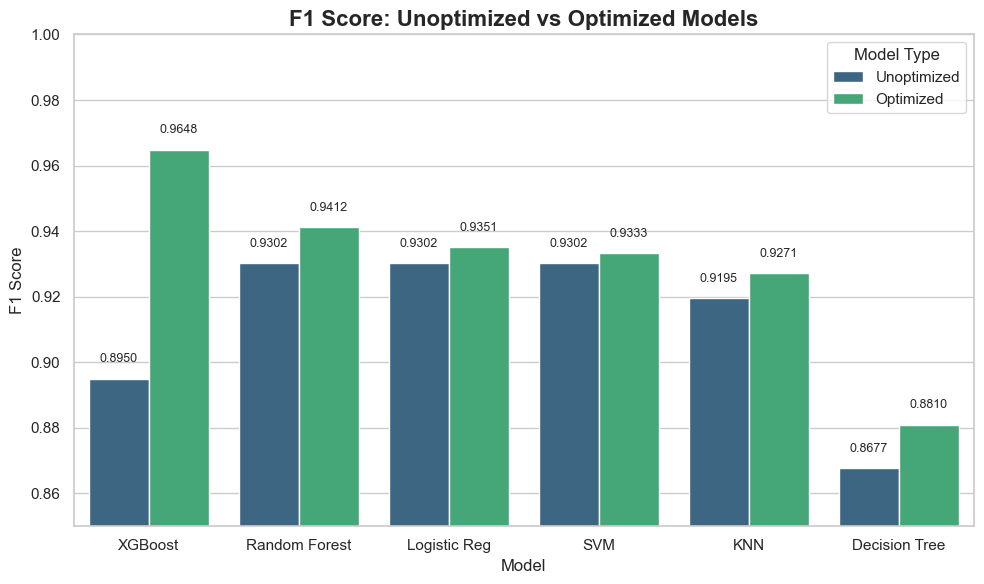

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

data = {
    'Model': ['XGBoost', 'Random Forest', 'Logistic Reg', 'SVM', 'KNN', 'Decision Tree'],
    'Unoptimized': [0.8950, 0.9302, 0.9302, 0.9302, 0.9195, 0.8677],
    'Optimized': [0.9648, 0.9412, 0.9351, 0.9333, 0.9271, 0.8810]
}

df_plot = pd.DataFrame(data).melt(id_vars='Model', var_name='Type', value_name='F1 Score')

plt.figure(figsize=(10, 6))
sns.barplot(data=df_plot, x='Model', y='F1 Score', hue='Type', palette='viridis')
plt.title('F1 Score: Unoptimized vs Optimized Models', fontsize=16, fontweight='bold')
plt.ylabel('F1 Score', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.ylim(0.85, 1.0)
plt.legend(title='Model Type')
for i, row in df_plot.iterrows():
    plt.text(i % 6 + (0.2 if 'Optimized' in row['Type'] else -0.2), 
             row['F1 Score'] + 0.005, f"{row['F1 Score']:.4f}", 
             ha='center', fontsize=9)
plt.tight_layout()
plt.show()

### In this chart before doing optimizing highest scored is random forest model and after optimized XGBoost model